In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
import os
os.chdir('..')
os.chdir('..')
os.getcwd()

'/Users/ak/Documents/GitHub/rise-project/pair_trading'

In [3]:
import numpy as np, random, os
import pandas as pd
from models import xgboost

np.random.seed(42)
random.seed(42)
os.environ["PYTHONHASHSEED"] = "42"

stock_pairs = [('AVGO','HOUS'), 
         ('AVGO','COMM'), 
         ('AVGO','VSAT'), 
         ('MSFT','HOUS'), 
         ('MSFT', 'COMM'),
         ('MSFT', 'VSAT'), 
         ('AAPL','HOUS'), 
         ('AAPL', 'COMM'), 
         ('AAPL','VSAT')]

tickers = sorted(set([stock for pair in stock_pairs for stock in pair]))

stock_train_prices = pd.read_csv("stocks/stock_train_prices.csv", index_col = 0, parse_dates = True)
stock_test_prices = pd.read_csv("stocks/stock_test_prices.csv", index_col = 0, parse_dates = True)

train_prices = stock_train_prices[tickers].dropna()
test_prices = stock_test_prices[tickers].dropna()

In [4]:
pair_models, pair_betas, feature_cols = xgboost.grid_search(stock_pairs, train_prices, test_prices)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.1s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.2s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.2s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.5s
[CV] END gamma=0, learning_rate=0.01, max_depth=6, min_child_weight=1; total time=   0.2s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, 

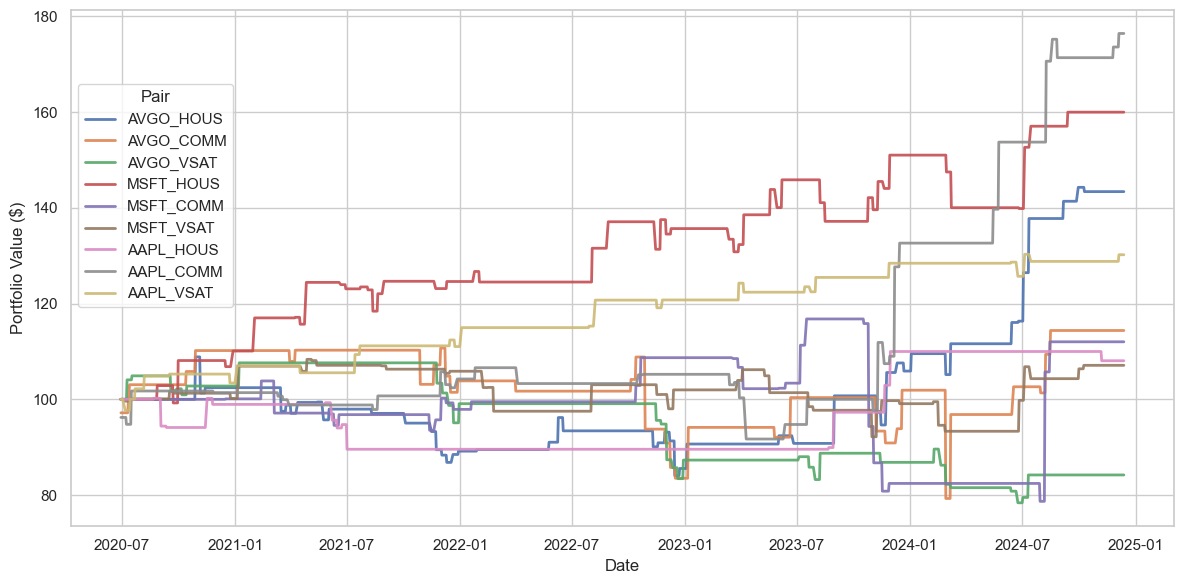

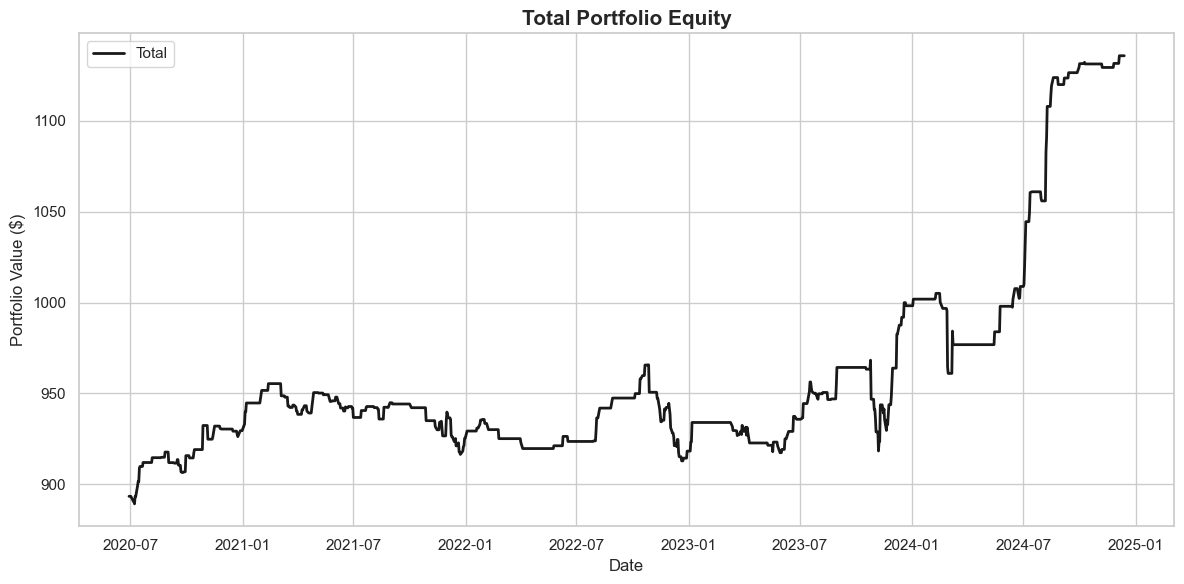

Summary
AVGO_HOUS: Final Value = $143.39, Total Return = 43.39%, Trades = 47
AVGO_COMM: Final Value = $114.38, Total Return = 17.69%, Trades = 32
AVGO_VSAT: Final Value = $84.20, Total Return = -15.80%, Trades = 31
MSFT_HOUS: Final Value = $160.00, Total Return = 60.00%, Trades = 46
MSFT_COMM: Final Value = $112.02, Total Return = 12.02%, Trades = 29
MSFT_VSAT: Final Value = $107.10, Total Return = 7.10%, Trades = 40
AAPL_HOUS: Final Value = $108.06, Total Return = 8.06%, Trades = 15
AAPL_COMM: Final Value = $176.44, Total Return = 83.37%, Trades = 36
AAPL_VSAT: Final Value = $130.21, Total Return = 30.21%, Trades = 28

Total Portfolio Performance
Initial Portfolio Value: $893.40
Final Portfolio Value:   $1,135.80
Total Return:            27.13%

Sharpe Ratios
AVGO_HOUS: Sharpe Ratio = 0.63
AVGO_COMM: Sharpe Ratio = 0.28
AVGO_VSAT: Sharpe Ratio = -0.37
MSFT_HOUS: Sharpe Ratio = 0.96
MSFT_COMM: Sharpe Ratio = 0.22
MSFT_VSAT: Sharpe Ratio = 0.21
AAPL_HOUS: Sharpe Ratio = 0.26
AAPL_COMM: 

Exception ignored in: <function ResourceTracker.__del__ at 0x10ee4da80>
Traceback (most recent call last):
  File "/opt/anaconda3/envs/rise-project/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/opt/anaconda3/envs/rise-project/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/opt/anaconda3/envs/rise-project/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1094a9a80>
Traceback (most recent call last):
  File "/opt/anaconda3/envs/rise-project/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/opt/anaconda3/envs/rise-project/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/opt/anaconda3/envs/rise-project/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child proces

In [ ]:
xgboost.run_simulation(stock_pairs, test_prices, pair_models, feature_cols, pair_betas)